<a href="https://colab.research.google.com/github/zydanne-costa/Ondas_ADCP_SCO_Mar_Nov_2025/blob/main/Hs_Ts_Dp_Vento_Correlacao.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Rotina para calcular as relações de onda x vento

1. Importar Bibliotecas e config de plot

In [30]:
# ==========================================================
# BIBLIOTECAS
# ==========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import seaborn as sns

# ==========================================================
# CONFIGURAÇÃO DE FONTE
# ==========================================================

plt.rcParams["font.family"] = "serif"

plt.rcParams["font.serif"] = [
    "Times New Roman",
    "DejaVu Serif",
    "Computer Modern Roman"
]

plt.rcParams["font.size"] = 15
plt.rcParams["axes.titlesize"] = 15
plt.rcParams["axes.labelsize"] = 15
plt.rcParams["legend.fontsize"] = 15
plt.rcParams["figure.titlesize"] = 15

2. Leitura e tratamento de dados

In [2]:
# ==========================================================
# CONEXÃO COM O GOOGLE DRIVE
# ==========================================================

from google.colab import drive

drive.mount("/content/drive")

# CAMINHOS DOS ARQUIVOS
arquivo_chu = (
    "/content/drive/MyDrive/Ondas/"
    "Dados/Refinados/WaveData/wwdata_chu.txt"
)

arquivo_sec = (
    "/content/drive/MyDrive/Ondas/"
    "Dados/Refinados/WaveData/wwdata_sec.txt"
)

# LEITURA DOS DADOS
chu = pd.read_csv(arquivo_chu, sep="\t")
sec = pd.read_csv(arquivo_sec, sep="\t")

# CONVERSÃO DAS DATAS
for df in [chu, sec]:

    df["DataHora"] = pd.to_datetime(df["DataHora"])

# REMOÇÃO DE VALORES AUSENTES
chu = chu.dropna(subset=["Hs", "Wd_vel_ms",
                         "Dp_deg", "Wd_dir_deg"])

sec = sec.dropna(subset=["Hs", "Wd_vel_ms",
                         "Dp_deg", "Wd_dir_deg"])

Mounted at /content/drive


In [3]:
# 0 = NaN
chu.loc[chu["Hs"] == 0, "Hs"] = np.nan
sec.loc[sec["Hs"] == 0, "Hs"] = np.nan

3. Hs

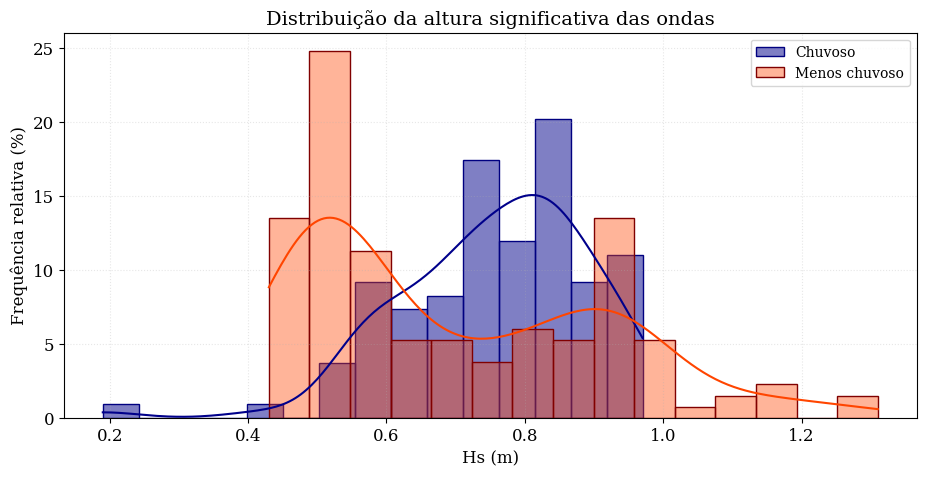

In [4]:
# ==========================================================
# FIGURA 1
# DISTRIBUIÇÃO DA ALTURA SIGNIFICATIVA (Hs)
# ==========================================================

fig, ax = plt.subplots(figsize=(11, 5))

sns.histplot(
    chu["Hs"],
    bins=15,
    stat="percent",
    kde=True,
    alpha=0.50,
    color="darkblue",
    edgecolor="navy",
    label="Chuvoso",
    ax=ax
)

sns.histplot(
    sec["Hs"],
    bins=15,
    stat="percent",
    kde=True,
    alpha=0.40,
    color="orangered",
    edgecolor="maroon",
    label="Menos chuvoso",
    ax=ax
)

ax.set_xlabel("Hs (m)")
ax.set_ylabel("Frequência relativa (%)")

ax.set_title(
    "Distribuição da altura significativa das ondas"
)

ax.grid(linestyle=":",linewidth=0.8,alpha=0.3)
ax.legend()

plt.show()

4. Veloc do vento

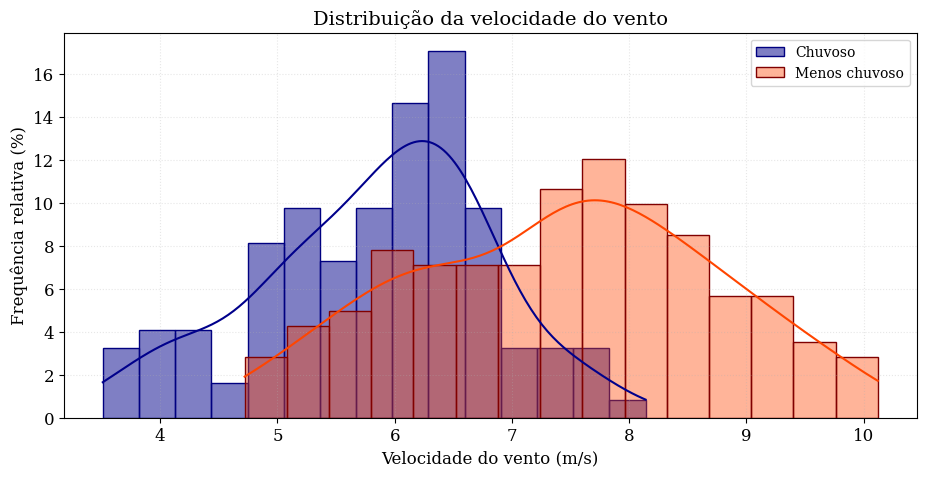

In [5]:
# ==========================================================
# FIGURA 2
# DISTRIBUIÇÃO DA VELOCIDADE DO VENTO
# ==========================================================

fig, ax = plt.subplots(figsize=(11, 5))

sns.histplot(
    chu["Wd_vel_ms"],
    bins=15,
    stat="percent",
    kde=True,
    alpha=0.50,
    color="darkblue",
    edgecolor="navy",
    label="Chuvoso",
    ax=ax
)

sns.histplot(
    sec["Wd_vel_ms"],
    bins=15,
    stat="percent",
    kde=True,
    alpha=0.40,
    color="orangered",
    edgecolor="maroon",
    label="Menos chuvoso",
    ax=ax
)

ax.set_xlabel("Velocidade do vento (m/s)")
ax.set_ylabel("Frequência relativa (%)")

ax.set_title(
    "Distribuição da velocidade do vento"
)

ax.grid(linestyle=":",linewidth=0.8,alpha=0.3)
ax.legend()

plt.show()

5. Histogramas Dir ondas x Vento

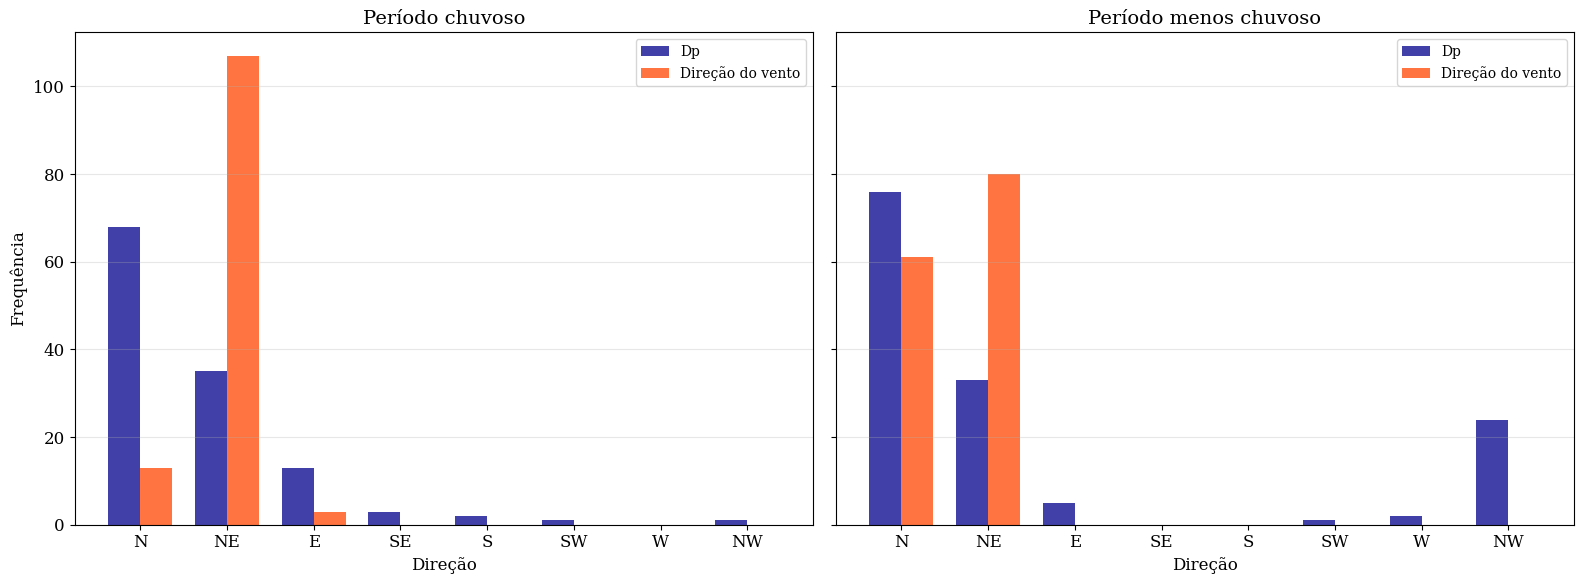

In [6]:
# ==========================================================
# CLASSIFICAÇÃO DAS DIREÇÕES
# ==========================================================

setores = ["N", "NE", "E", "SE",
            "S", "SW", "W", "NW"]

def direcao_cardeal(angulo):

    if pd.isna(angulo):
        return np.nan

    angulo = angulo % 360

    indice = int(((angulo + 22.5) % 360) // 45)

    return setores[indice]

# ==========================================================
# CLASSIFICAÇÃO DOS DADOS
# ==========================================================

for df in [chu, sec]:

    df["Dp_card"] = df["Dp_deg"].apply(direcao_cardeal)

    df["Wd_card"] = (
        df["Wd_dir_deg"].apply(direcao_cardeal)
    )

# ==========================================================
# CONTAGEM DAS OCORRÊNCIAS
# ==========================================================

dp_chu = (
    chu["Dp_card"]
    .value_counts()
    .reindex(setores, fill_value=0)
)

wd_chu = (
    chu["Wd_card"]
    .value_counts()
    .reindex(setores, fill_value=0)
)

dp_sec = (
    sec["Dp_card"]
    .value_counts()
    .reindex(setores, fill_value=0)
)

wd_sec = (
    sec["Wd_card"]
    .value_counts()
    .reindex(setores, fill_value=0)
)

# ==========================================================
# CONSTRUÇÃO DOS GRÁFICOS
# ==========================================================

x = np.arange(len(setores))

largura = 0.37

fig, ax = plt.subplots(
    1,
    2,
    figsize=(16, 6),
    sharey=True
)

# ----------------------------------------------------------
# PERÍODO CHUVOSO
# ----------------------------------------------------------

ax[0].bar(
    x - largura/2,
    dp_chu.values,
    width=largura,
    color="darkblue",
    alpha=0.75,
    label="Dp"
)

ax[0].bar(
    x + largura/2,
    wd_chu.values,
    width=largura,
    color="orangered",
    alpha=0.75,
    label="Direção do vento"
)

ax[0].set_xticks(x)
ax[0].set_xticklabels(setores)

ax[0].set_title("Período chuvoso")
ax[0].set_xlabel("Direção")
ax[0].set_ylabel("Frequência")

ax[0].grid(axis="y", alpha=0.30)

ax[0].legend()

# ----------------------------------------------------------
# PERÍODO MENOS CHUVOSO
# ----------------------------------------------------------

ax[1].bar(
    x - largura/2,
    dp_sec.values,
    width=largura,
    color="darkblue",
    alpha=0.75,
    label="Dp"
)

ax[1].bar(
    x + largura/2,
    wd_sec.values,
    width=largura,
    color="orangered",
    alpha=0.75,
    label="Direção do vento"
)

ax[1].set_xticks(x)
ax[1].set_xticklabels(setores)

ax[1].set_title("Período menos chuvoso")
ax[1].set_xlabel("Direção")

ax[1].grid(axis="y", alpha=0.30)

ax[1].legend()

plt.tight_layout()

plt.show()

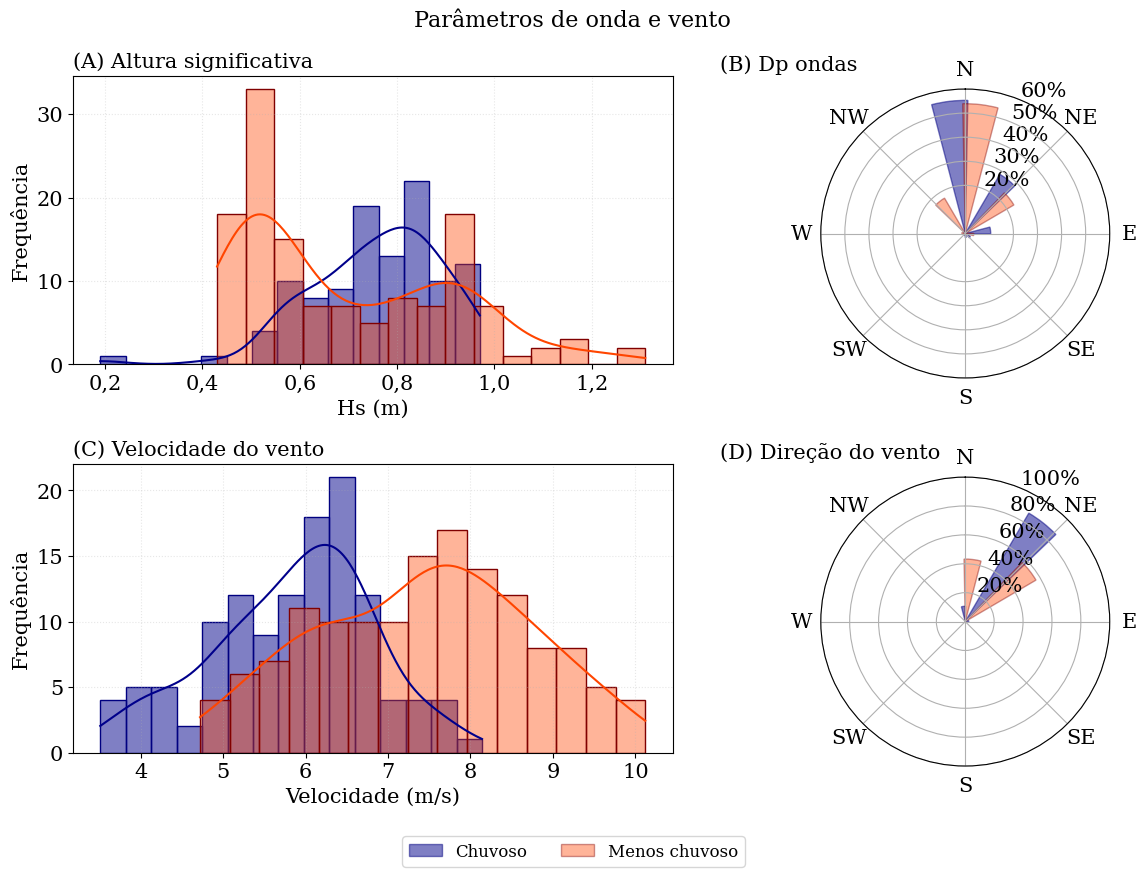

In [95]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import seaborn as sns

# ==========================================================
# FIGURA 4
# COMPARAÇÃO ONDAS x VENTO
#
# Painel 2x2
#
# (A) Hs
# (B) Rosa direcional - Dp
# (C) Velocidade do vento
# (D) Rosa direcional - direção do vento
# ==========================================================

# ==========================================================
# CONVERTE DIREÇÃO EM PONTOS CARDEAIS (8 SETORES)
# ==========================================================

setores = ["N","NE","E","SE","S","SW","W","NW"]

def direcao_cardeal(angulo):

    if pd.isna(angulo):
        return np.nan

    angulo = angulo % 360

    indice = int(((angulo+22.5)%360)//45)

    return setores[indice]


for df in [chu,sec]:

    df["Dp_card"] = df["Dp_deg"].apply(direcao_cardeal)

    df["Wd_card"] = df["Wd_dir_deg"].apply(direcao_cardeal)


# ==========================================================
# FREQUÊNCIA DAS DIREÇÕES
# ==========================================================

dp_chu = (
    chu["Dp_card"]
    .value_counts(normalize=True)
    .reindex(setores,fill_value=0)
    *100
)

dp_sec = (
    sec["Dp_card"]
    .value_counts(normalize=True)
    .reindex(setores,fill_value=0)
    *100
)

wd_chu = (
    chu["Wd_card"]
    .value_counts(normalize=True)
    .reindex(setores,fill_value=0)
    *100
)

wd_sec = (
    sec["Wd_card"]
    .value_counts(normalize=True)
    .reindex(setores,fill_value=0)
    *100
)

# ==========================================================
# FIGURA
# ==========================================================

fig = plt.figure(figsize=(13,9))

# ----------------------------------------------------------
# (A) HISTOGRAMA Hs
# ----------------------------------------------------------

ax1 = plt.subplot(2,2,1)

sns.histplot(
    chu["Hs"],
    bins=15,
    stat="count",
    kde=True,
    alpha=0.50,
    color="darkblue",
    edgecolor="navy",
    linewidth=1,
    label="Chuvoso",
    ax=ax1
)

sns.histplot(
    sec["Hs"],
    bins=15,
    stat="count",
    kde=True,
    alpha=0.40,
    color="orangered",
    edgecolor="maroon",
    linewidth=1,
    label="Menos chuvoso",
    ax=ax1
)

ax1.set_title("(A) Altura significativa", loc='left')

ax1.set_xlabel("Hs (m)")
ax1.set_ylabel("Frequência")

ax1.grid(
    linestyle=":",
    linewidth=0.8,
    alpha=0.30
)

ax1.xaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"{x:.1f}".replace(".", ","))
)

# ----------------------------------------------------------
# (B) ROSA DIRECIONAL DAS ONDAS
# ----------------------------------------------------------

ax2 = plt.subplot(
    2,
    2,
    2,
    projection="polar"
)

ang = np.linspace(0,2*np.pi,8,endpoint=False)

larg = 2*np.pi/8

ax2.bar(
    ang-larg*0.15,
    dp_chu.values,
    width=larg*0.35,
    alpha=0.50,
    color="darkblue",
    edgecolor="navy",
    linewidth=1,
    label="Chuvoso"
)

ax2.bar(
    ang+larg*0.15,
    dp_sec.values,
    width=larg*0.35,
    alpha=0.40,
    color="orangered",
    edgecolor="maroon",
    linewidth=1,
    label="Menos chuvoso"
)

ax2.set_theta_zero_location("N")
ax2.set_theta_direction(-1)

ax2.set_xticks(ang)
ax2.set_xticklabels(setores,fontsize=15)

limite = np.ceil(max(dp_chu.max(), dp_sec.max())/20)*20

ax2.set_ylim(0, limite)

ticks = np.arange(20, limite+1, 10)

ax2.set_yticks(ticks)
ax2.set_yticklabels([f"{i:.0f}%" for i in ticks])

ax2.set_title("(B) Dp ondas", loc='left', x=-0.35, y=1.0355)


# ----------------------------------------------------------
# (C) HISTOGRAMA VENTO
# ----------------------------------------------------------

ax3 = plt.subplot(2,2,3)

sns.histplot(
    chu["Wd_vel_ms"],
    bins=15,
    stat="count",
    kde=True,
    alpha=0.50,
    color="darkblue",
    edgecolor="navy",
    linewidth=1,
    label="Chuvoso",
    ax=ax3
)

sns.histplot(
    sec["Wd_vel_ms"],
    bins=15,
    stat="count",
    kde=True,
    alpha=0.40,
    color="orangered",
    edgecolor="maroon",
    linewidth=1,
    label="Menos chuvoso",
    ax=ax3
)

ax3.set_title("(C) Velocidade do vento", loc='left')

ax3.set_xlabel("Velocidade (m/s)")
ax3.set_ylabel("Frequência")

ax3.grid(
    linestyle=":",
    linewidth=0.8,
    alpha=0.30
)

#ax3.xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{x:.1f}".replace(".", ",")))

#ax3.yaxis.set_major_formatter( FuncFormatter(lambda y, pos: f"{y:.1f}".replace(".", ",")))

# ----------------------------------------------------------
# (D) ROSA DIRECIONAL DO VENTO
# ----------------------------------------------------------

ax4 = plt.subplot(
    2,
    2,
    4,
    projection="polar"
)

ax4.bar(
    ang-larg*0.15,
    wd_chu.values,
    width=larg*0.35,
    alpha=0.50,
    color="darkblue",
    edgecolor="navy",
    linewidth=1,
    label="Chuvoso"
)

ax4.bar(
    ang+larg*0.15,
    wd_sec.values,
    width=larg*0.35,
    alpha=0.40,
    color="orangered",
    edgecolor="maroon",
    linewidth=1,
    label="Menos chuvoso"
)

ax4.set_theta_zero_location("N")
ax4.set_theta_direction(-1)

ax4.set_xticks(ang)
ax4.set_xticklabels(setores,fontsize=15)

limite = np.ceil(max(wd_chu.max(), wd_sec.max())/20)*20

ax4.set_ylim(0, limite)

ticks = np.arange(20, limite+1, 20)

ax4.set_yticks(ticks)
ax4.set_yticklabels([f"{i:.0f}%" for i in ticks])

ax4.set_title("(D) Direção do vento", loc='left', x=-0.35, y=1.0355)

# ==========================================================
# LEGENDA GERAL
# ==========================================================

handles, labels = ax4.get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="lower center",
    ncol=2,
    fontsize=12
)

fig.suptitle("Parâmetros de onda e vento",fontsize=16,x=0.45,y=0.96)

plt.tight_layout(rect=[0,0.05,1,1])

for ax in [ax2, ax4]:
    pos = ax.get_position()
    ax.set_position([pos.x0, pos.y0-0.015, pos.width, pos.height])

plt.savefig(
    "/content/drive/MyDrive/Ondas/Resultados_dissertacao/Vento_Onda/Figura_Onda_Vento.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()